# Trabalho Prático 2 — Ciência de Dados
## Inflação sobre bens de consumo: Brasil e o mundo

### Objetivo

Este notebook inicia uma análise da evolução da inflação sobre bens de consumo ao consumidor, com seções que focam na comparação do Brasil com outros países e regiões do mundo.

Dataset utilizado disponível em:

*Observação: o indicador mede a variação percentual anual dos preços ao consumidor. Portanto, ele representa uma **taxa de inflação**, e não o nível absoluto de preços nem o custo de uma cesta específica de bens.

## 1. Bibliotecas

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from scipy import stats
from IPython.display import display

## 2. Carregamento dos dados

O CSV do World Bank possui linhas introdutórias antes do cabeçalho. Por isso, neste arquivo, "skiprows=4" é utilizado no dataset principal. Os metadados não precisam receber o mesmo tratamento.

In [33]:
with open("./API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_368812.csv", "r", encoding="utf-8-sig") as file:
    inflation_csv = file.read()

with open("./Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_368812.csv", "r", encoding="utf-8-sig") as file:
    metadata_csv = file.read()

inflation_df = pd.read_csv(StringIO(inflation_csv), skiprows=4)
country_meta = pd.read_csv(StringIO(metadata_csv))

print("Dataset principal:", inflation_df.shape)
print("Metadata:", country_meta.shape)

Dataset principal: (265, 71)
Metadata: (264, 6)


## 3. Estrutura inicial

O dataset principal apresenta os anos como colunas, isto é, está no formato **wide**. As colunas de identificação são `Country Name`, `Country Code`, `Indicator Name` e `Indicator Code`.

Os anos de 1960 a 2025 serão identificados automaticamente para evitar depender de uma lista digitada manualmente.

In [34]:
year_columns = [c for c in inflation_df.columns if str(c).isdigit()]

print("Primeiro ano:", year_columns[0])
print("Último ano:", year_columns[-1])
print("Quantidade de anos:", len(year_columns))

display(inflation_df.head())

Primeiro ano: 1960
Último ano: 2025
Quantidade de anos: 66


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,4.270111,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,1.657818,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020,NaN


### 4. Classificação entre País ou região

Como não existem somente países no dataset, pode ser útil separar regiões agregadas para não afetar cálculos de média, por exemplo

In [35]:
def classificar(row):
    if pd.isna(row["Region"]):
        return "Aggregated"
    else:
        return "Country"

## 5. Normalização dos tipos

As colunas anuais serão convertidas para valores numéricos. Valores vazios do CSV são transformados em `NaN`, permitindo que o Pandas os reconheça como dados ausentes.

Não será feita imputação nesta etapa. Primeiro é necessário medir a cobertura dos dados para decidir quais anos e quais entidades podem sustentar a análise.

In [36]:
country_meta["Type"] = country_meta.apply(classificar, axis=1)

inflation_df = inflation_df.merge(
    country_meta[["Country Code", "Region", "IncomeGroup", "Type"]],
    on="Country Code", how="left"
)

inflation_df = inflation_df.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"],
                                 errors="ignore")

year_columns = [col for col in inflation_df.columns if col.isdigit()]
inflation_df[year_columns] = inflation_df[year_columns].apply(pd.to_numeric, errors="coerce")

#Separação entre países e agregados
countries_df = inflation_df[inflation_df["Type"] == "Country"]
aggregates_df = inflation_df[inflation_df["Type"] == "Aggregated"]

print("Quantidade total de valores ausentes:")
print(inflation_df[year_columns].isna().sum().sum())

display(inflation_df[["Country Name", "Country Code"] + year_columns[:5]].head())

Quantidade total de valores ausentes:
6018


,Country Name,Country Code,1960,1961,1962,1963,1964
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN


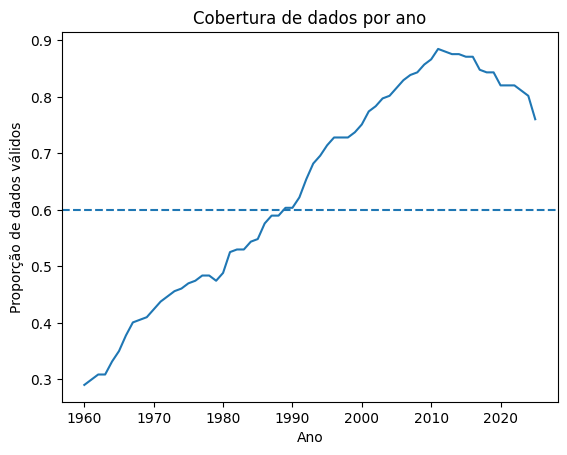

In [37]:
# Definir mínimo de dados para ser considerado válido
# Anos com pelo menos 60% de dados válidos
coverage = countries_df[year_columns].notna().mean()
valid_years = list(coverage[coverage >= 0.60].index)

coverage.plot()

plt.axhline(0.60, linestyle='--')
plt.title("Cobertura de dados por ano")
plt.ylabel("Proporção de dados válidos")
plt.xlabel("Ano")

plt.show()

In [38]:
country_meta["Type"] = np.where(
    country_meta["Region"].notna(),
    "Country",
    "Aggregated"
)

metadata_columns = [
    "Country Code",
    "Region",
    "IncomeGroup",
    "Type"
]

id_columns = ["Country Name", "Country Code", "Region", "IncomeGroup"]

#Transformando o dataset do formato wide para long
inflation_raw_long = countries_df[id_columns + valid_years].melt(
    id_vars=id_columns,
    value_vars=valid_years,
    var_name="Year",
    value_name="Inflation Rate"
)
inflation_raw_long["Year"] = inflation_raw_long["Year"].astype(int)
inflation_raw_long = inflation_raw_long.sort_values(["Country Code", "Year"])

# Versão preenchida (interpolação + média do país)
inflation_df_long = inflation_raw_long.copy()
inflation_df_long["Inflation Rate"] = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform(
    lambda x: x.interpolate(method="linear", limit=3, limit_direction="both")
)

#Substituição pela média do país caso ainda haja lacunas:
country_mean = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform("mean")
inflation_df_long["Inflation Rate"] = inflation_df_long["Inflation Rate"].fillna(country_mean)

# Drop, caso ainda haja lacunas:
inflation_df_long = inflation_df_long.dropna(subset=["Inflation Rate"])

inflation_raw_long = inflation_raw_long.dropna(subset=["Inflation Rate"])

print("Anos válidos:", valid_years[0], "a", valid_years[-1])
print("Observações sem preenchimento:", len(inflation_raw_long))
print("Observações com preenchimento:", len(inflation_df_long))
display(inflation_raw_long.groupby("Region")["Inflation Rate"].describe())

Anos válidos: 1989 a 2025
Observações sem preenchimento: 6311
Observações com preenchimento: 7141


,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
East Asia & Pacific,962.0,5.324823,11.952590,-4.009434,1.364939,3.132120,6.179295,268.150489
Europe & Central Asia,1632.0,29.082417,198.351998,-10.630097,1.662405,3.150187,7.706362,4734.914347
Latin America & Caribbean,1159.0,27.115304,274.552699,-7.113768,2.060981,4.261051,8.299114,7481.663611
Middle East & North Africa,741.0,8.959277,27.831078,-16.117326,1.589094,3.483407,8.249890,448.500000
North America,73.0,2.521406,1.462995,-0.355546,1.621216,2.258394,2.951657,8.002800
South Asia,222.0,6.865291,5.022737,-4.763860,3.839101,6.277942,8.909331,49.721102
Sub-Saharan Africa,1522.0,40.554423,637.449200,-16.859691,2.516531,5.927773,11.396403,23773.131774


## Atenção:

O preenchimento pela média do país distorce rankings quando faltam muitos anos seguidos.
A República Democrática do Congo não tem dados de 2017 a 2025 e, como sua média histórica é
puxada pela hiperinflação de 1994, o preenchimento atribui a ela mais de 1000% de inflação em
todos esses anos — o que a colocaria falsamente como o país mais inflacionário de 2025.

Por isso, os rankings e máximos desta seção usam o `inflation_raw_long` (somente valores
observados), enquanto médias e medianas agregadas podem usar o `inflation_df_long`.

In [39]:
congo_raw = inflation_raw_long[inflation_raw_long["Country Code"] == "COD"]
congo_filled = inflation_df_long[inflation_df_long["Country Code"] == "COD"]

print("Último ano observado para o Congo:", congo_raw["Year"].max())
print("Valor preenchido em 2025:")
display(congo_filled[congo_filled["Year"] == 2025][["Country Name", "Year", "Inflation Rate"]])

Último ano observado para o Congo: 2016
Valor preenchido em 2025:


,Country Name,Year,Inflation Rate
7851,"Congo, Dem. Rep.",2025,1123.098151


## Quais países tiveram o aumento mais brusco de inflação (Maior pico)?

Como a inflação varia de valores negativos a mais de 20000%, os gráficos comparativos usam
escala logarítmica. Em escala linear, um único episódio de hiperinflação achata todo o resto.

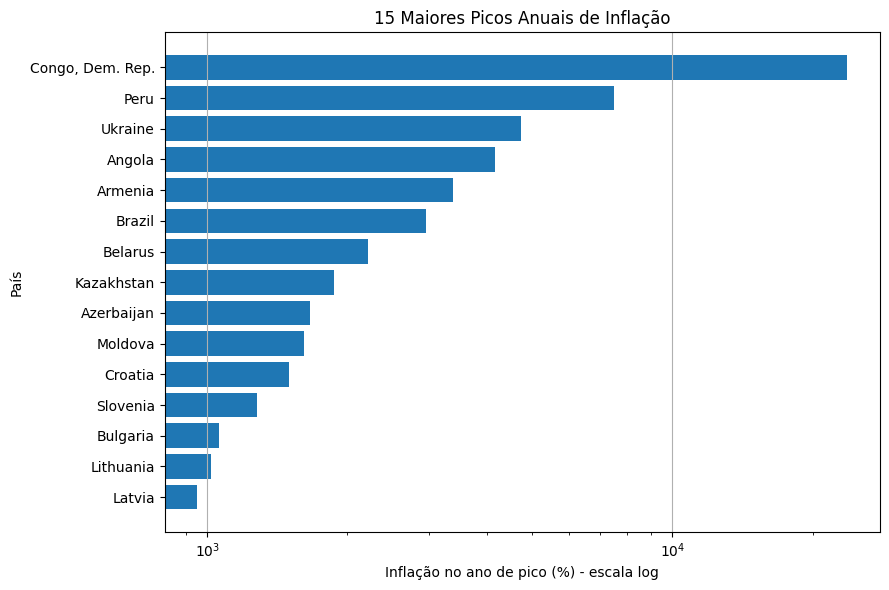

,Country Name,Year,Inflation Rate
1124,"Congo, Dem. Rep.",1994,23773.131774
369,Peru,1990,7481.663611
1069,Ukraine,1993,4734.914347
1521,Angola,1996,4145.105982
1092,Armenia,1994,3373.759443
243,Brazil,1990,2947.732772
1107,Belarus,1994,2221.016570
1184,Kazakhstan,1994,1877.372395
1097,Azerbaijan,1994,1662.215949
990,Moldova,1993,1613.603989


In [40]:
# Ano de pico de cada país
peak_index = inflation_raw_long.groupby("Country Name")["Inflation Rate"].idxmax()
peaks = inflation_raw_long.loc[peak_index]

top_peaks = peaks.nlargest(15, "Inflation Rate").sort_values("Inflation Rate")

plt.figure(figsize=(9, 6))
plt.barh(top_peaks["Country Name"], top_peaks["Inflation Rate"])
plt.xscale("log")
plt.title("15 Maiores Picos Anuais de Inflação")
plt.xlabel("Inflação no ano de pico (%) - escala log")
plt.ylabel("País")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

display(top_peaks.sort_values("Inflation Rate", ascending=False)[["Country Name", "Year", "Inflation Rate"]])

## É importante notar que:

Os picos se concentram em duas janelas históricas: a transição pós-socialista (Ucrânia,
Armênia, Bielorrússia, Cazaquistão, Azerbaijão, entre 1993 e 1994) e as crises
latino-americanas do fim dos anos 1980 (Peru, Brasil, Argentina). O maior valor da base é o da
República Democrática do Congo em 1994, com 23773%.

O Brasil aparece em 6º lugar, com 2948% em 1990 — o ápice do ciclo que antecedeu o Plano Real.
Nenhum pico dessa magnitude ocorre depois de 1997 na base.

2.3 Inflação elevada não é o mesmo que inflação brusca

O gráfico anterior mede a intensidade do pior ano. Este mede persistência: em quantos anos o
país teve inflação de dois dígitos.

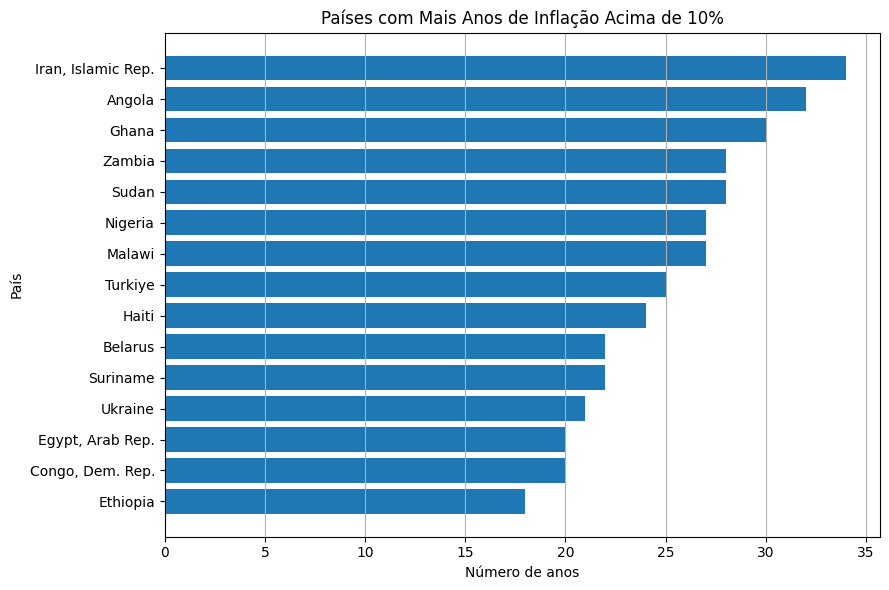

Brasil: 9 anos com inflação >= 10%, em 37 anos observados
Anos em que o Brasil teve inflação >= 10%:
[1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 2003]


In [41]:
high_inflation = inflation_raw_long[inflation_raw_long["Inflation Rate"] >= 10]

years_high = high_inflation.groupby("Country Name").size()
years_observed = inflation_raw_long.groupby("Country Name").size()

top_persistent = years_high.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_persistent.index, top_persistent.values)
plt.title("Países com Mais Anos de Inflação Acima de 10%")
plt.xlabel("Número de anos")
plt.ylabel("País")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

print("Brasil:", years_high["Brazil"], "anos com inflação >= 10%,",
      "em", years_observed["Brazil"], "anos observados")
print("Anos em que o Brasil teve inflação >= 10%:")
print(sorted(high_inflation[high_inflation["Country Name"] == "Brazil"]["Year"].tolist()))

In [42]:
brasil = inflation_df_long[inflation_df_long["Country Code"] == "BRA"].dropna(subset=["Inflation Rate"])
regiao = inflation_df_long[
    (inflation_df_long["Region"] == "Latin America & Caribbean") &
    (inflation_df_long["Country Code"] != "BRA")
].dropna(subset=["Inflation Rate"])

2.4 Países que mais reduziram a inflação

A comparação usa a mediana de dois períodos de 11 anos, no início e no fim da janela de
análise. A mediana evita que um único ano de hiperinflação defina o período inteiro. Só entram
países com pelo menos 6 observações em cada período.

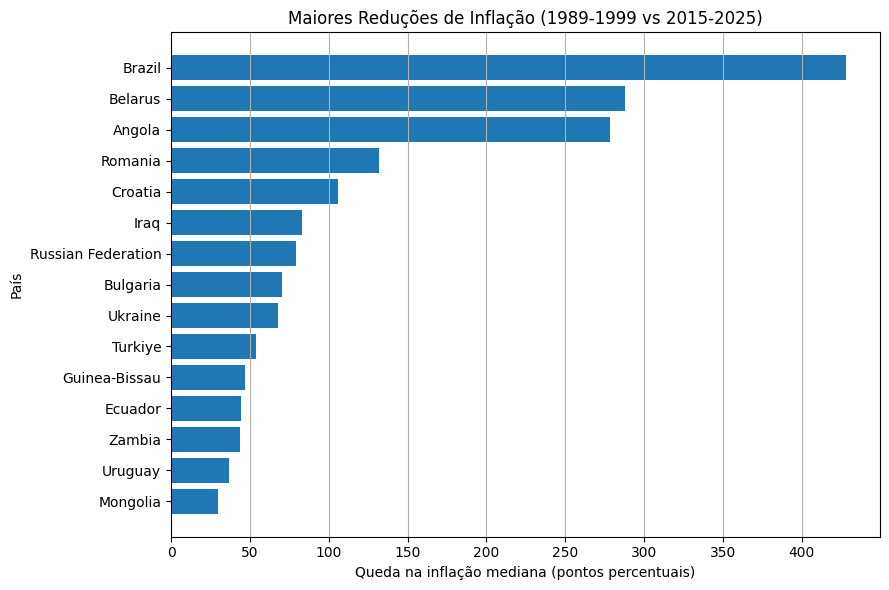

,median_early,median_late,Reduction
Country Name,,,
Brazil,432.786662,4.593563,428.193099
Belarus,293.678751,6.031837,287.646914
Angola,299.509804,21.355290,278.154514
Romania,136.759393,4.625484,132.133908
Croatia,107.327586,1.500125,105.827461
Iraq,83.615819,0.574163,83.041657
Russian Federation,85.746494,6.694459,79.052035
Bulgaria,72.878791,2.814545,70.064247
Ukraine,80.325501,12.730334,67.595167


In [43]:
early = inflation_raw_long[(inflation_raw_long["Year"] >= 1989) & (inflation_raw_long["Year"] <= 1999)]
late = inflation_raw_long[inflation_raw_long["Year"] >= 2015]

early_median = early.groupby("Country Name")["Inflation Rate"].agg(["median", "size"])
late_median = late.groupby("Country Name")["Inflation Rate"].agg(["median", "size"])

comparison = early_median.merge(late_median, on="Country Name", suffixes=("_early", "_late"))
comparison = comparison[(comparison["size_early"] >= 6) & (comparison["size_late"] >= 6)]
comparison["Reduction"] = comparison["median_early"] - comparison["median_late"]

top_reduction = comparison.nlargest(15, "Reduction").sort_values("Reduction")

plt.figure(figsize=(9, 6))
plt.barh(top_reduction.index, top_reduction["Reduction"])
plt.title("Maiores Reduções de Inflação (1989-1999 vs 2015-2025)")
plt.xlabel("Queda na inflação mediana (pontos percentuais)")
plt.ylabel("País")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

display(top_reduction.sort_values("Reduction", ascending=False)[["median_early", "median_late", "Reduction"]])

## Note que:

O Brasil lidera o ranking mundial de redução: a mediana cai de 433% (1989-1999) para 4,6%
(2015-2025), uma queda de 428 pontos percentuais e uma razão de aproximadamente 94 vezes.

Dois pontos merecem atenção. Primeiro, os campeões de redução são quase os mesmos países do
ranking de picos — reduzir muito é, em grande medida, ter tido muito o que reduzir. Segundo, o
nível de chegada importa mais que o tamanho da queda: Angola (21,4%), Turquia (16,3%) e Ucrânia
(12,7%) despencaram, mas terminaram o período ainda em dois dígitos, enquanto o Brasil chegou a
um dígito.

Pergunta: dado que um país é da América Latina, qual a probabilidade de estar em um "ano de inflação alta" (ex: acima do percentil 75 mundial)?

2.6 Trajetória da inflação brasileira

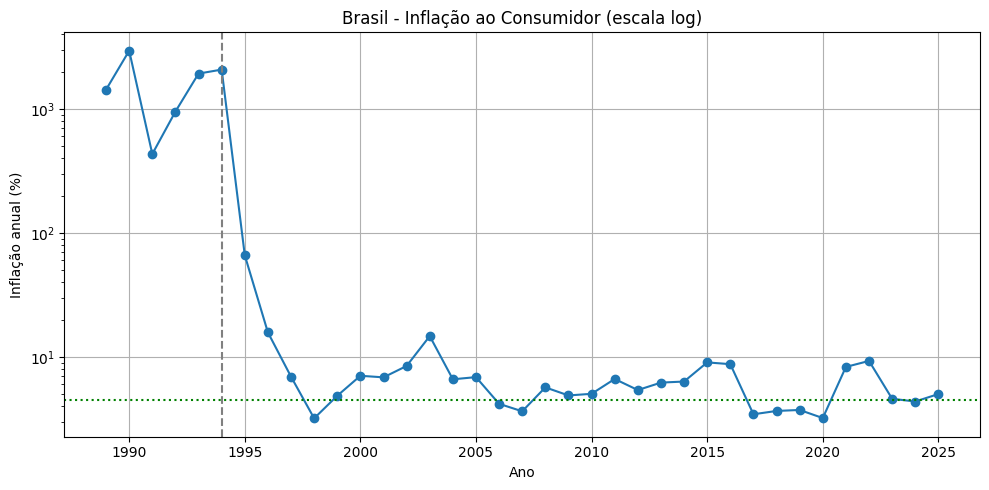

Linha vertical: Plano Real (1994). Linha horizontal: centro da meta atual (4,5%)


,Year,Inflation Rate
6319,2018,3.664850
6536,2019,3.732976
6753,2020,3.211768
6970,2021,8.301660
7187,2022,9.280106
7404,2023,4.593563
7621,2024,4.367464
7838,2025,5.016753


In [44]:
brazil = inflation_raw_long[inflation_raw_long["Country Code"] == "BRA"].sort_values("Year")

plt.figure(figsize=(10, 5))
plt.plot(brazil["Year"], brazil["Inflation Rate"], marker="o")
plt.yscale("log")
plt.axvline(x=1994, linestyle="--", color="gray")
plt.axhline(y=4.5, linestyle=":", color="green")
plt.title("Brasil - Inflação ao Consumidor (escala log)")
plt.xlabel("Ano")
plt.ylabel("Inflação anual (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Linha vertical: Plano Real (1994). Linha horizontal: centro da meta atual (4,5%)")
display(brazil[brazil["Year"] >= 2018][["Year", "Inflation Rate"]])

Insight: a escala logarítmica separa três regimes bem distintos. Hiperinflação até 1994,
queda de três ordens de grandeza em cerca de dois anos, e um regime pós-1996 que oscila em
torno de um dígito. Desde 1999 o Brasil nunca voltou aos dois dígitos, mas também raramente se
mantém abaixo do centro da meta. O pico recente de 2021 e 2022 coincide com o choque global de
preços pós-pandemia.

2.7 Brasil comparado às regiões do mundo

Aqui são usados os agregados do Banco Mundial, que estavam separados na classificação por
`Type`.

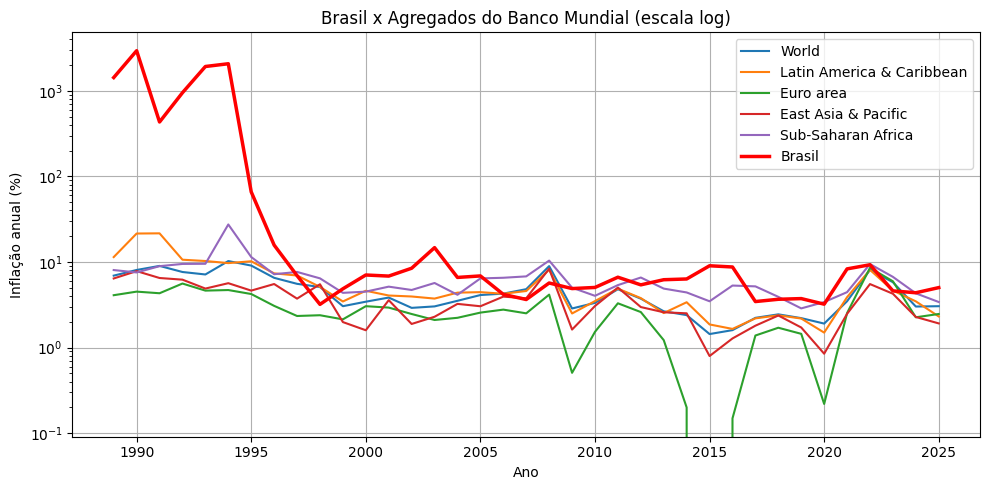

In [45]:
regions = ["World", "Latin America & Caribbean", "Euro area",
           "East Asia & Pacific", "Sub-Saharan Africa"]

aggregates_long = aggregates_df[["Country Name"] + valid_years].melt(
    id_vars=["Country Name"],
    value_vars=valid_years,
    var_name="Year",
    value_name="Inflation Rate"
)
aggregates_long["Year"] = aggregates_long["Year"].astype(int)
aggregates_long = aggregates_long.dropna(subset=["Inflation Rate"])

plt.figure(figsize=(10, 5))

for region in regions:
    df_plot = aggregates_long[aggregates_long["Country Name"] == region].sort_values("Year")
    plt.plot(df_plot["Year"], df_plot["Inflation Rate"], label=region)

plt.plot(brazil["Year"], brazil["Inflation Rate"], label="Brasil", linewidth=2.5, color="red")
plt.yscale("log")
plt.title("Brasil x Agregados do Banco Mundial (escala log)")
plt.xlabel("Ano")
plt.ylabel("Inflação anual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

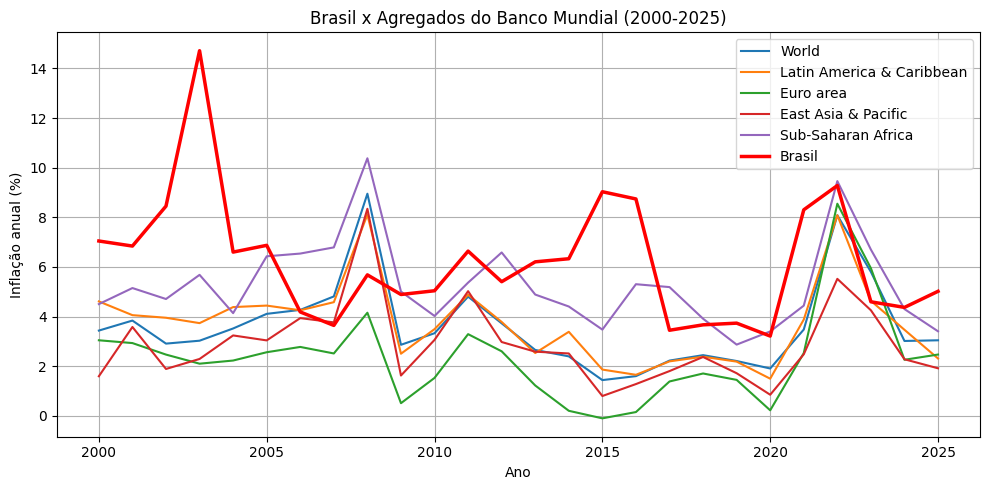

In [46]:
# Mesmo gráfico a partir de 2000, em escala linear
plt.figure(figsize=(10, 5))

for region in regions:
    df_plot = aggregates_long[
        (aggregates_long["Country Name"] == region) & (aggregates_long["Year"] >= 2000)
    ].sort_values("Year")
    plt.plot(df_plot["Year"], df_plot["Inflation Rate"], label=region)

brazil_recent = brazil[brazil["Year"] >= 2000]
plt.plot(brazil_recent["Year"], brazil_recent["Inflation Rate"], label="Brasil",
         linewidth=2.5, color="red")

plt.title("Brasil x Agregados do Banco Mundial (2000-2025)")
plt.xlabel("Ano")
plt.ylabel("Inflação anual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Note que:

Depois de 1996 o Brasil passa a orbitar a mesma faixa dos agregados regionais, mas de forma
consistente acima da zona do euro e, em quase todos os anos, acima também da média da América
Latina e Caribe e da média mundial.

Em 2021 e 2022 todas as séries sobem juntas, o que sugere um componente externo. A seção 3
testa essa hipótese formalmente, e o resultado contraria a leitura visual.

2.8 Evolução da inflação mediana por região e por grupo de renda

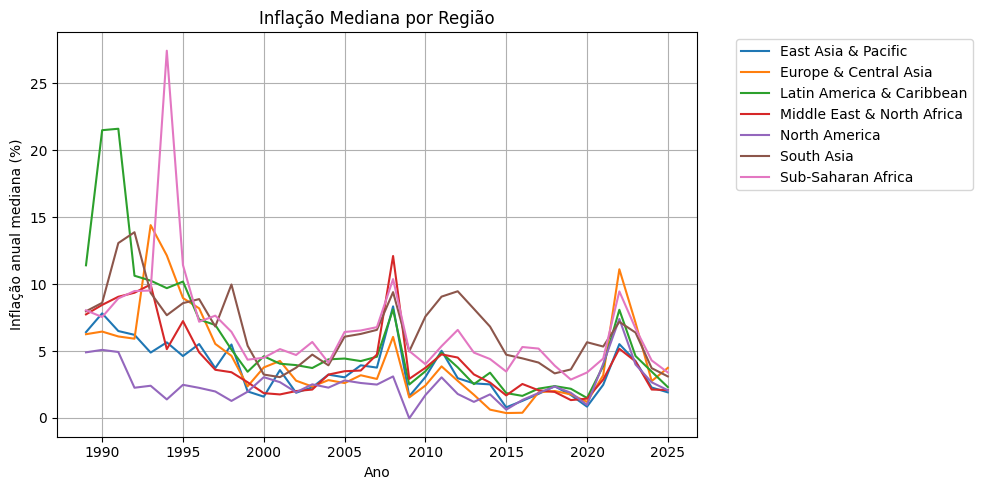

Inflação mediana por região, 2015-2025:


Region
South Asia                    4.796035
Sub-Saharan Africa            4.526002
Latin America & Caribbean     3.088337
Europe & Central Asia         2.556131
Middle East & North Africa    2.408830
East Asia & Pacific           2.149962
North America                 2.130110
Name: Inflation Rate, dtype: float64

In [47]:
region_year = inflation_raw_long.groupby(["Year", "Region"])["Inflation Rate"].median().reset_index()

plt.figure(figsize=(10, 5))

for region in region_year["Region"].unique():
    df_plot = region_year[region_year["Region"] == region]
    plt.plot(df_plot["Year"], df_plot["Inflation Rate"], label=region)

plt.title("Inflação Mediana por Região")
plt.xlabel("Ano")
plt.ylabel("Inflação anual mediana (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Inflação mediana por região, 2015-2025:")
display(inflation_raw_long[inflation_raw_long["Year"] >= 2015]
        .groupby("Region")["Inflation Rate"].median().sort_values(ascending=False))

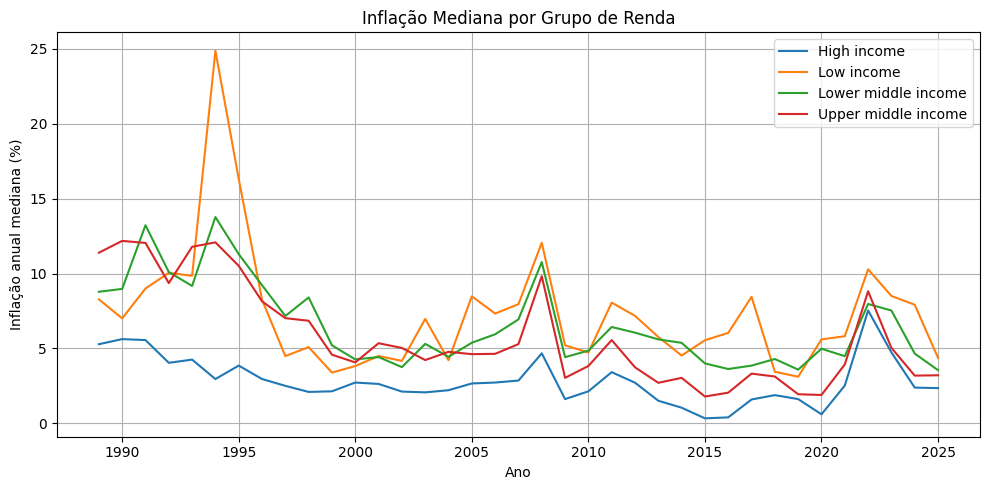

Inflação mediana por grupo de renda, 2015-2025, e valor do Brasil:


IncomeGroup
Low income             6.464722
Lower middle income    4.815062
Upper middle income    3.238016
High income            1.880384
Name: Inflation Rate, dtype: float64

Brasil (renda média-alta): 4.59


In [48]:
income_year = inflation_raw_long.groupby(["Year", "IncomeGroup"])["Inflation Rate"].median().reset_index()

plt.figure(figsize=(10, 5))

for group in income_year["IncomeGroup"].unique():
    df_plot = income_year[income_year["IncomeGroup"] == group]
    plt.plot(df_plot["Year"], df_plot["Inflation Rate"], label=group)

plt.title("Inflação Mediana por Grupo de Renda")
plt.xlabel("Ano")
plt.ylabel("Inflação anual mediana (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Inflação mediana por grupo de renda, 2015-2025, e valor do Brasil:")
display(inflation_raw_long[inflation_raw_long["Year"] >= 2015]
        .groupby("IncomeGroup")["Inflation Rate"].median().sort_values(ascending=False))
print("Brasil (renda média-alta):",
      round(brazil[brazil["Year"] >= 2015]["Inflation Rate"].median(), 2))

## Note que:
A mediana de 2015-2025 vai de 1,9% nos países de renda alta a 6,5% nos de renda baixa.

O Brasil é classificado como renda média-alta e tem mediana de 4,6% no período, acima da
mediana do seu próprio grupo (3,2%) e mais próximo do padrão dos países de renda média-baixa.
Logo, o nível de renda possui influência considerável nos índices

# Aplicação do teorema de bayes: 
probabilidade condicional de inflação alta Define-se um "ano de inflação alta" como aquele em que a taxa de um país supera o *percentil 75* da distribuição mundial de todas as observações país-ano. 

In [49]:
limiar = inflation_df_long["Inflation Rate"].quantile(0.75)
inflation_df_long["alta_inflacao"] = inflation_df_long["Inflation Rate"] > limiar

p_alta_geral = inflation_df_long["alta_inflacao"].mean()
p_alta_lac = inflation_df_long.loc[
    inflation_df_long["Region"] == "Latin America & Caribbean", "alta_inflacao"
].mean()
p_alta_brasil = brasil["Inflation Rate"].gt(limiar).mean()

print(f"Limiar de 'inflação alta' (percentil 75 mundial): {limiar:.2f}%")
print(f"P(alta inflação) geral: {p_alta_geral:.2%}")
print(f"P(alta inflação | região = América Latina e Caribe): {p_alta_lac:.2%}")
print(f"P(alta inflação | país = Brasil): {p_alta_brasil:.2%}")

# Teorema de Bayes explícito: P(LAC | alta) = P(alta | LAC) * P(LAC) / P(alta)
p_lac = (inflation_df_long["Region"] == "Latin America & Caribbean").mean()
p_lac_dado_alta = (p_alta_lac * p_lac) / p_alta_geral

print(f"\nP(região = América Latina e Caribe | alta inflação), via Bayes: {p_lac_dado_alta:.2%}")

Limiar de 'inflação alta' (percentil 75 mundial): 9.01%
P(alta inflação) geral: 25.00%
P(alta inflação | região = América Latina e Caribe): 24.47%
P(alta inflação | país = Brasil): 29.73%

P(região = América Latina e Caribe | alta inflação), via Bayes: 18.26%


# Conclusão

A análise mostra que inflação brusca e inflação elevada são fenômenos diferentes. Os maiores
picos da base são episódios concentrados entre 1989 e 1997, ligados a colapsos monetários em
transições políticas, enquanto a inflação persistente de dois dígitos aparece em países como
Irã, Angola e Gana, que raramente figuram entre os picos extremos.

O Brasil pertence ao primeiro grupo e é o país que mais reduziu inflação no mundo no período
analisado, saindo de uma mediana de 433% nos anos 1990 para 4,6% na última década. A quebra de
regime associada ao Plano Real é estatisticamente significativa e permanente: desde 1999 o país
nunca voltou aos dois dígitos.

A comparação internacional, porém, mostra que a estabilização não se converteu em convergência.
A inflação brasileira é significativamente maior que a dos países de renda média-alta e que a da
própria América Latina, em um excesso estruturalmente estável, e não há evidência de que esse
excesso esteja diminuindo. O Brasil tem hoje uma inflação pouco volátil, porém ancorada em um
patamar alto para o seu grupo de comparação — o problema da hiperinflação foi resolvido, o da
convergência para padrões de renda alta não.

Vale registrar, por fim, uma limitação da própria base: os países com inflação mais grave são
justamente os que param de reportar dados, como Venezuela, Sudão e Zimbábue. Qualquer ranking
construído a partir deste dataset subestima a cauda mais extrema da distribuição mundial.